<a href="https://colab.research.google.com/github/kvssri/online-tihiitg/blob/main/task_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [21]:
from google.colab import files

uploaded = files.upload()

Saving Underwater-Image-Data-set-main.zip to Underwater-Image-Data-set-main (1).zip


In [22]:
import zipfile
import os

zip_file = list(uploaded.keys())[0]

with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall('/content/project_data')

print("Main ZIP extracted successfully!")

Main ZIP extracted successfully!


In [23]:
import glob

seven_zip_files = glob.glob('/content/project_data/**/*.7z', recursive=True)

print("Total .7z files found:", len(seven_zip_files))

for file in seven_zip_files:
    print(file)

Total .7z files found: 8
/content/project_data/Underwater-Image-Data-set-main/epoch_0115.7z
/content/project_data/Underwater-Image-Data-set-main/epoch_0120.7z
/content/project_data/Underwater-Image-Data-set-main/epoch_0100.7z
/content/project_data/Underwater-Image-Data-set-main/epoch_100.7z
/content/project_data/Underwater-Image-Data-set-main/epoch_0096.7z
/content/project_data/Underwater-Image-Data-set-main/epoch_00100.7z
/content/project_data/Underwater-Image-Data-set-main/epoch_0110.7z
/content/project_data/Underwater-Image-Data-set-main/epoch_0135.7z


In [24]:
!apt-get install p7zip-full -y

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
p7zip-full is already the newest version (16.02+dfsg-8).
0 upgraded, 0 newly installed, 0 to remove and 1 not upgraded.


In [25]:
import os
import glob

seven_zip_files = glob.glob('/content/project_data/**/*.7z', recursive=True)

for file in seven_zip_files:
    output_folder = file.replace('.7z', '')
    os.makedirs(output_folder, exist_ok=True)

    print("Extracting:", file)
    !7z x "{file}" -o"{output_folder}" -y

print("All .7z files extracted!")

Extracting: /content/project_data/Underwater-Image-Data-set-main/epoch_0115.7z

7-Zip [64] 16.02 : Copyright (c) 1999-2016 Igor Pavlov : 2016-05-21
p7zip Version 16.02 (locale=en_US.UTF-8,Utf16=on,HugeFiles=on,64 bits,2 CPUs Intel(R) Xeon(R) CPU @ 2.20GHz (406F0),ASM,AES-NI)

Scanning the drive for archives:
  0M Scan /content/project_data/Underwater-Image-Data-set-main/                                                               1 file, 23128645 bytes (23 MiB)

Extracting archive: /content/project_data/Underwater-Image-Data-set-main/epoch_0115.7z
--
Path = /content/project_data/Underwater-Image-Data-set-main/epoch_0115.7z
Type = 7z
Physical Size = 23128645
Headers Size = 4780
Method = LZMA:23
Solid = +
Blocks = 1

  0%      6% - epoch_0115/img 100_gen.png                                 

In [26]:
image_files = []

for root, dirs, files in os.walk('/content/project_data'):
    for file in files:
        if file.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.webp')):
            image_files.append(os.path.join(root, file))

print("Total images found:", len(image_files))

print("\nFirst 10 images:")
for img in image_files[:10]:
    print(img)

Total images found: 3694

First 10 images:
/content/project_data/Underwater-Image-Data-set-main/epoch_0115/epoch_0115/img 33_gen.png
/content/project_data/Underwater-Image-Data-set-main/epoch_0115/epoch_0115/img 37_input.png
/content/project_data/Underwater-Image-Data-set-main/epoch_0115/epoch_0115/img 27_target.png
/content/project_data/Underwater-Image-Data-set-main/epoch_0115/epoch_0115/img 37_target.png
/content/project_data/Underwater-Image-Data-set-main/epoch_0115/epoch_0115/img 125_gen.png
/content/project_data/Underwater-Image-Data-set-main/epoch_0115/epoch_0115/img 96_input.png
/content/project_data/Underwater-Image-Data-set-main/epoch_0115/epoch_0115/img 24_target.png
/content/project_data/Underwater-Image-Data-set-main/epoch_0115/epoch_0115/img 70_gen.png
/content/project_data/Underwater-Image-Data-set-main/epoch_0115/epoch_0115/img 110_target.png
/content/project_data/Underwater-Image-Data-set-main/epoch_0115/epoch_0115/img 35_gen.png


In [27]:
from PIL import Image
import pandas as pd

image_info = []

for path in image_files:
    try:
        img = Image.open(path)

        image_info.append({
            'filename': os.path.basename(path),
            'path': path,
            'width': img.width,
            'height': img.height,
            'mode': img.mode,
            'format': img.format
        })

    except Exception as e:
        print("Could not read:", path)

image_df = pd.DataFrame(image_info)

print("Total valid images:", len(image_df))
display(image_df.head())

Total valid images: 3694


,filename,path,width,height,mode,format
0,img 33_gen.png,/content/project_data/Underwater-Image-Data-se...,256,256,RGB,PNG
1,img 37_input.png,/content/project_data/Underwater-Image-Data-se...,256,256,RGB,PNG
2,img 27_target.png,/content/project_data/Underwater-Image-Data-se...,256,256,RGB,PNG
3,img 37_target.png,/content/project_data/Underwater-Image-Data-se...,256,256,RGB,PNG
4,img 125_gen.png,/content/project_data/Underwater-Image-Data-se...,256,256,RGB,PNG


In [28]:
print("Image Dimension Distribution:")

dimension_counts = (
    image_df.groupby(['width', 'height'])
    .size()
    .reset_index(name='count')
    .sort_values('count', ascending=False)
)

display(dimension_counts.head(10))

Image Dimension Distribution:


,width,height,count
0,256,256,3694


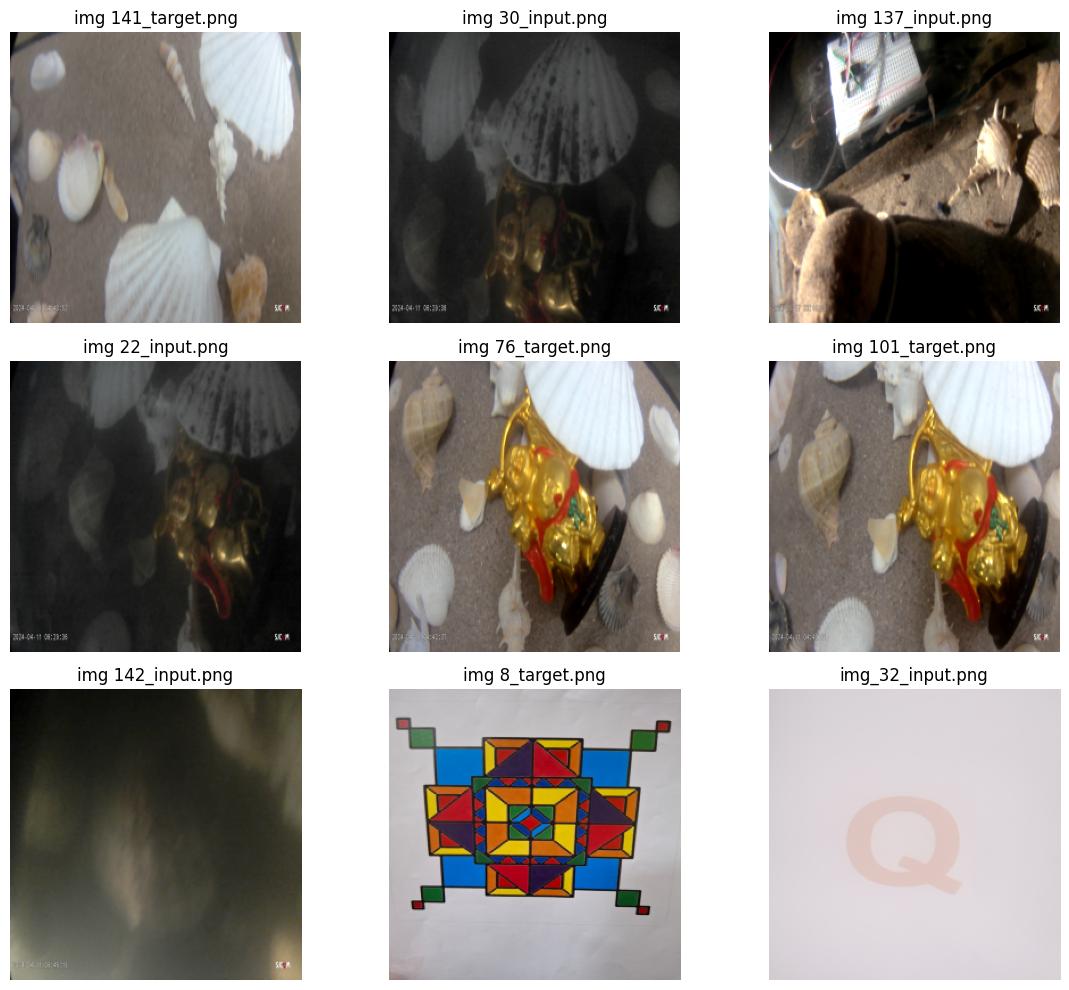

In [29]:
import random
import matplotlib.pyplot as plt

sample_count = min(9, len(image_files))
samples = random.sample(image_files, sample_count)

plt.figure(figsize=(12, 10))

for i, path in enumerate(samples):
    img = Image.open(path).convert('RGB')

    plt.subplot(3, 3, i + 1)
    plt.imshow(img)
    plt.title(os.path.basename(path))
    plt.axis('off')

plt.tight_layout()
plt.show()

In [30]:
import numpy as np

def get_brightness(path):
    img = Image.open(path).convert('RGB')
    arr = np.array(img)
    return arr.mean()

brightness_data = []

for path in image_files:
    try:
        brightness_data.append({
            'path': path,
            'brightness': get_brightness(path)
        })
    except:
        pass

brightness_df = pd.DataFrame(brightness_data)

dark_samples = brightness_df.nsmallest(
    min(6, len(brightness_df)),
    'brightness'
)

display(dark_samples)

,path,brightness
3580,/content/project_data/Underwater-Image-Data-se...,0.974294
3685,/content/project_data/Underwater-Image-Data-se...,2.615275
3421,/content/project_data/Underwater-Image-Data-se...,3.498886
3415,/content/project_data/Underwater-Image-Data-se...,3.962728
3244,/content/project_data/Underwater-Image-Data-se...,3.980647
381,/content/project_data/Underwater-Image-Data-se...,6.449514


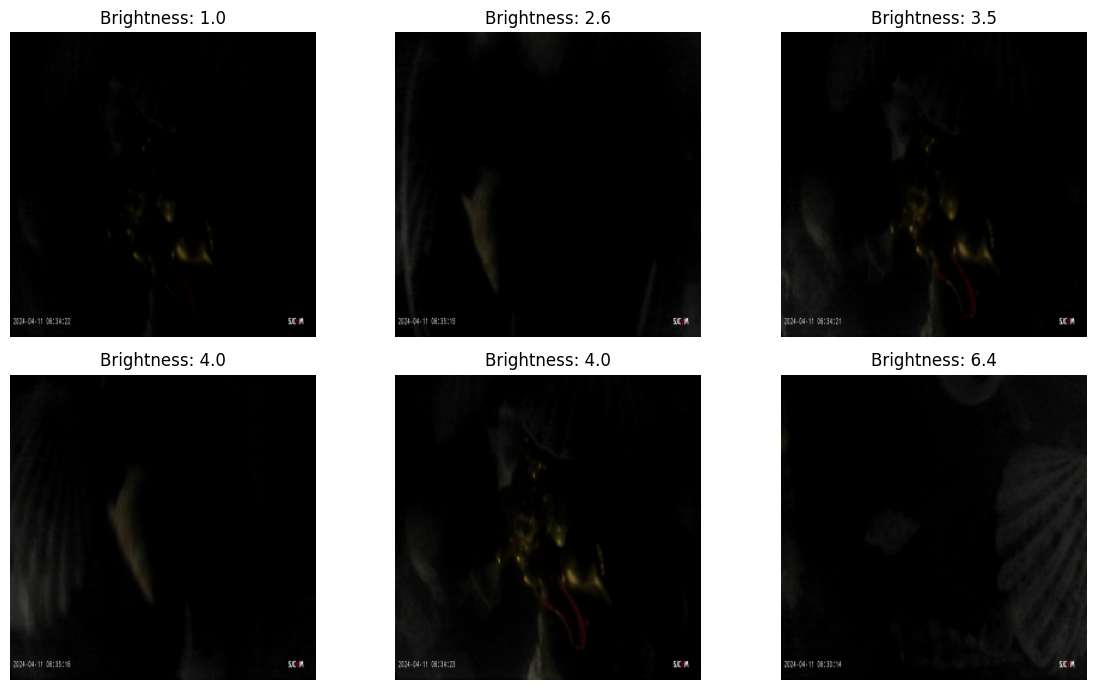

In [31]:
plt.figure(figsize=(12, 7))

for i, (_, row) in enumerate(dark_samples.iterrows()):
    img = Image.open(row['path']).convert('RGB')

    plt.subplot(2, 3, i + 1)
    plt.imshow(img)
    plt.title(f"Brightness: {row['brightness']:.1f}")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [32]:
corrupted_images = []

for path in image_files:
    try:
        img = Image.open(path)
        img.verify()
    except:
        corrupted_images.append(path)

print("Total corrupted images:", len(corrupted_images))

Total corrupted images: 0


In [33]:
print("Image Formats:")
print(image_df['format'].value_counts())

print("\nImage Color Modes:")
print(image_df['mode'].value_counts())

Image Formats:
format
PNG    3694
Name: count, dtype: int64

Image Color Modes:
mode
RGB    3694
Name: count, dtype: int64
